<a href="https://colab.research.google.com/github/RITHANYA-R-B/ElectroVision---HACKZEN-2026-Open-Challenge/blob/main/basic_electronic_component_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 127.7 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO
from roboflow import Roboflow
from google.colab import files
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:


from roboflow import Roboflow
rf = Roboflow(api_key="jYHFj6VYCH3xkxjbrRkm")
project = rf.workspace("rukhsar-ktyd9").project("basic-electronic-component-24urw-dphfg")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Basic-electronic-component-1 in yolov8:: 100%|██████████| 1887/1887 [00:00<00:00, 7459.48it/s]


In [5]:
model = YOLO("yolov8n.pt")

In [6]:
model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    project="Electronic_Component_Project",
    name="component_detector"
)

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Basic-electronic-component-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=component_detector, nbs=64, nms=False, opset=None, optimize=False,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79e2dac4b9e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.

In [8]:
model = YOLO("/content/runs/detect/Electronic_Component_Project/component_detector/weights/best.pt")

print("✅ Trained Model Loaded")

✅ Trained Model Loaded


In [45]:
uploaded = files.upload()

Saving project 1.jpg to project 1 (2).jpg


In [46]:
image_path = list(uploaded.keys())[0]

results = model(image_path, save=True)

print("✅ Detection Complete")


image 1/1 /content/project 1 (2).jpg: 480x640 1 Resistor, 1 Transistor, 7.5ms
Speed: 2.4ms preprocess, 7.5ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict
✅ Detection Complete


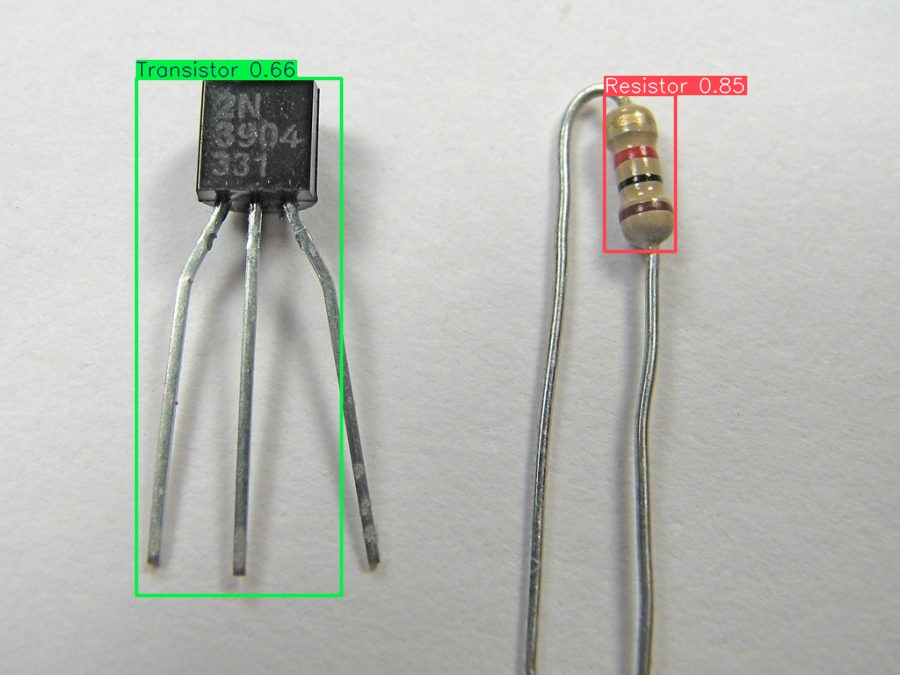

In [47]:
Image.open("runs/detect/predict/" + image_path)

In [48]:
detected = []

for r in results:
    for box in r.boxes:

        cls = int(box.cls)

        name = model.names[cls]

        detected.append(name)

        print(name)

Resistor
Transistor


In [49]:
counter = Counter(detected)

print("Electronic Components Detected\n")

for component, count in counter.items():
    print(f"{component}: {count}")

Electronic Components Detected

Resistor: 1
Transistor: 1


In [50]:
component_info = {

    "Resistor": {
        "Function": "Limits the flow of electric current.",
        "Application": "Current limiting and voltage division."
    },

    "Capacitor": {
        "Function": "Stores electrical energy.",
        "Application": "Filtering, timing circuits, power supply smoothing."
    },

    "Diode": {
        "Function": "Allows current to flow in only one direction.",
        "Application": "Rectifiers and reverse polarity protection."
    },

    "LED": {
        "Function": "Emits light when current flows.",
        "Application": "Indicators and displays."
    },

    "IC": {
        "Function": "Integrated circuit performing electronic operations.",
        "Application": "Microcontrollers, amplifiers, logic circuits."
    },

    "Transistor": {
        "Function": "Acts as an electronic switch or amplifier.",
        "Application": "Switching and signal amplification."
    }
}

In [52]:
shown = set()

for component in detected:

    if component in shown:
        continue

    shown.add(component)

    print("=" * 50)
    print("Detected:", component)

    if component in component_info:

        print("Function:")
        print(component_info[component]["Function"])

        print()

        print("Application:")
        print(component_info[component]["Application"])

    else:
        print("Information not available.")

Detected: Resistor
Function:
Limits the flow of electric current.

Application:
Current limiting and voltage division.
Detected: Transistor
Function:
Acts as an electronic switch or amplifier.

Application:
Switching and signal amplification.
